# 电动汽车购买意愿预测：数据探索

**任务类型：** 二分类概率预测（目标列 `Will_Buy_EV`）  
**数据来源：** `data/train.csv`、`data/test.csv`、`data/sample_submission.csv`  
**比赛时间：** 2026-09-01 开始；最终提交及团队合并截止时间为 2026-09-30 23:59 UTC。

本 Notebook 面向后续建模，依次检查数据结构、质量、目标分布、单变量关系、训练/测试分布一致性和提交文件约束。数据是受真实 EV adoption behavior 数据启发的合成数据，因此下文只讨论预测关联，不作因果解释。

## tl;dr

- 训练集有 **668,665** 行、15 列；测试集有 **286,571** 行、14 列。两者均无缺失值和整行重复，且 train/test 的类别集合一致。
- 目标 `Will_Buy_EV` 的正类（`Yes`）比例为 **17.46%**，存在明显类别不平衡；交叉验证应采用分层切分，并同时关注概率排序与校准。
- 单变量层面，`Environmental_Concern_Level` 与目标的线性相关最高（约 **0.464**），其次是 `Annual_Income_USD`（约 **0.226**）。
- 类别变量中，补贴可用时的正类率约 **27.47%**，无补贴时约 **0.58%**；低里程焦虑组约 **18.90%**，高里程焦虑组约 **0.14%**。这些差异是强预测信号，但并不证明因果关系。
- `id` 在 train/test 中不重叠且连续衔接，应仅用于行标识和提交，不进入模型。训练与测试的主要特征分布整体接近，后文提供可复算的漂移表。

## Context & Methods

### 目标

1. 确认数据可用于建模，排查缺失、重复、取值异常和 train/test 字段不一致。
2. 描述目标不平衡及各特征与购买意愿的单变量关联。
3. 检查 train/test 分布漂移，为交叉验证和特征工程提供依据。

### Key Assumptions

- `Will_Buy_EV == "Yes"` 定义为正类 1，`"No"` 定义为负类 0。
- `id` 是提交键而不是行为特征；连续编号可能携带数据生成顺序，不应被模型利用。
- 题面未给出官方评价指标，因此本 Notebook 不假定具体指标；建模阶段需以 Kaggle 竞赛页公布的指标为准。
- 所有图表均基于当前本地 CSV；Notebook 使用固定随机种子抽样绘制大规模分布图，不影响汇总统计。

## Data

### 1. 环境与路径设置

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TARGET = "Will_Buy_EV"
ID_COL = "id"

# 同时兼容从项目根目录或 notebooks/ 目录运行。
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"

COLORS = {
    "blue": "#3569A8",
    "gold": "#D6A72C",
    "orange": "#D97941",
    "olive": "#7A8B45",
    "pink": "#B65C7A",
    "gray": "#A8AFB8",
    "charcoal": "#30343B",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titleweight": "bold",
    "axes.edgecolor": "#68707A",
    "axes.labelcolor": COLORS["charcoal"],
    "text.color": COLORS["charcoal"],
    "grid.color": "#D9DDE2",
    "grid.linewidth": 0.7,
})

print(f"项目根目录: {PROJECT_ROOT}")
print(f"数据目录存在: {DATA_DIR.exists()}")

项目根目录: E:\kaggle\Predicting Electric Vehicle Purchases
数据目录存在: True


### 2. 读取数据

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

target_binary = train[TARGET].map({"No": 0, "Yes": 1})
assert target_binary.notna().all(), "目标列包含 Yes/No 以外的取值。"

numeric_features = [
    c for c in test.columns
    if c != ID_COL and pd.api.types.is_numeric_dtype(test[c])
]
categorical_features = [
    c for c in test.columns
    if c != ID_COL and not pd.api.types.is_numeric_dtype(test[c])
]

dataset_overview = pd.DataFrame({
    "数据集": ["train", "test", "sample_submission"],
    "行数": [len(train), len(test), len(sample_submission)],
    "列数": [train.shape[1], test.shape[1], sample_submission.shape[1]],
    "内存_MB": [
        train.memory_usage(deep=True).sum() / 2**20,
        test.memory_usage(deep=True).sum() / 2**20,
        sample_submission.memory_usage(deep=True).sum() / 2**20,
    ],
})
dataset_overview_display = dataset_overview.copy()
dataset_overview_display["行数"] = dataset_overview_display["行数"].map(lambda x: f"{x:,}")
dataset_overview_display["内存_MB"] = dataset_overview_display["内存_MB"].map(lambda x: f"{x:.1f}")
display(dataset_overview_display)
display(train.head(5))

,数据集,行数,列数,内存_MB
0,train,"668,665",15,276.5
1,test,"286,571",14,104.5
2,sample_submission,"286,571",2,4.4


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


### 3. 字段结构与数据质量

In [3]:
schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "non_null": train.notna().sum(),
    "missing": train.isna().sum(),
    "unique": train.nunique(dropna=False),
}).rename_axis("feature")
display(schema)

quality_summary = pd.DataFrame({
    "train": [train.isna().sum().sum(), train.duplicated().sum(), train[ID_COL].duplicated().sum()],
    "test": [test.isna().sum().sum(), test.duplicated().sum(), test[ID_COL].duplicated().sum()],
}, index=["缺失单元格", "重复整行", "重复 id"])
display(quality_summary)

expected_test_columns = [c for c in train.columns if c != TARGET]
assert test.columns.tolist() == expected_test_columns, "train/test 特征列或顺序不一致。"
assert train[ID_COL].is_unique and test[ID_COL].is_unique, "id 必须唯一。"
assert set(train[ID_COL]).isdisjoint(set(test[ID_COL])), "train/test id 不应重叠。"
assert sample_submission[ID_COL].equals(test[ID_COL]), "sample_submission 与 test 的 id/顺序不一致。"

category_check = pd.DataFrame({
    "train_categories": [sorted(train[c].unique().tolist()) for c in categorical_features],
    "test_categories": [sorted(test[c].unique().tolist()) for c in categorical_features],
}, index=categorical_features)
category_check["same_set"] = category_check["train_categories"] == category_check["test_categories"]
display(category_check)
print("所有结构与键值检查均通过。")

,dtype,non_null,missing,unique
feature,,,,
id,int64,668665,0,668665
Age,int64,668665,0,45
Annual_Income_USD,float64,668665,0,13214
Daily_Commute_km,float64,668665,0,805
Number_of_Cars_Owned,int64,668665,0,4
Charging_Stations_Near_Home,int64,668665,0,15
Charging_Stations_Near_Work,int64,668665,0,20
Environmental_Concern_Level,float64,668665,0,5
Gender,str,668665,0,3


,train,test
缺失单元格,0,0
重复整行,0,0
重复 id,0,0


,train_categories,test_categories,same_set
Gender,"[Female, Male, Other]","[Female, Male, Other]",True
City_Type,"[Rural, Suburban, Urban]","[Rural, Suburban, Urban]",True
Current_Car_Type,"[Hatchback, SUV, Sedan, Truck]","[Hatchback, SUV, Sedan, Truck]",True
Home_Charging_Possible,"[No, Yes]","[No, Yes]",True
Subsidy_Available,"[No, Yes]","[No, Yes]",True
Range_Anxiety_Level,"[High, Low, Medium]","[High, Low, Medium]",True


所有结构与键值检查均通过。


**质量结论：** 当前文件没有缺失值、重复行或重复 `id`；训练与测试特征完全对齐，样例提交的 `id` 与测试集顺序一致。即便如此，建模流水线仍应保留缺失值处理，以防未来数据版本变化。

## Results

### 4. 目标分布

,样本数,比例
Will_Buy_EV,,
No,"551,886",82.54%
Yes,"116,779",17.46%


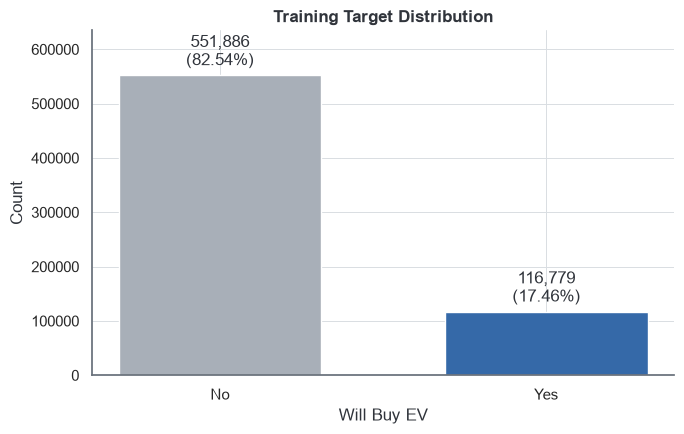

In [4]:
target_counts = train[TARGET].value_counts().reindex(["No", "Yes"])
target_rates = target_counts / len(train)
target_table = pd.DataFrame({"样本数": target_counts, "比例": target_rates})
target_table_display = target_table.copy()
target_table_display["样本数"] = target_table_display["样本数"].map(lambda x: f"{x:,}")
target_table_display["比例"] = target_table_display["比例"].map(lambda x: f"{x:.2%}")
display(target_table_display)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(target_counts.index, target_counts.values,
              color=[COLORS["gray"], COLORS["blue"]], width=0.62)
ax.set(title="Training Target Distribution", xlabel="Will Buy EV", ylabel="Count")
ax.set_ylim(0, target_counts.max() * 1.15)
ax.bar_label(
    bars,
    labels=[f"{n:,}\n({r:.2%})" for n, r in zip(target_counts, target_rates)],
    padding=4,
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

正类只占 17.46%，准确率会被多数类主导。后续应使用分层交叉验证；若官方指标关注概率质量，可同时监控 ROC-AUC、PR-AUC、Log Loss 与 Brier Score，并仅以官方指标进行模型选择。

### 5. 数值特征范围与分布

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
Age,668665.0,47.039,12.875,25.0,25.0,36.0,47.0,58.0,69.0,69.0,-0.004
Annual_Income_USD,668665.0,84769.267,28648.029,30000.0,30000.0,67376.0,84880.0,102753.0,151159.0,188549.0,-0.013
Daily_Commute_km,668665.0,32.158,18.730,5.0,5.0,17.2,33.6,47.4,68.5,98.7,-0.085
Number_of_Cars_Owned,668665.0,1.713,0.729,1.0,1.0,1.0,2.0,2.0,4.0,4.0,0.814
Charging_Stations_Near_Home,668665.0,4.960,3.927,0.0,0.0,2.0,4.0,7.0,14.0,14.0,0.699
Charging_Stations_Near_Work,668665.0,7.176,5.187,0.0,0.0,3.0,6.0,10.0,19.0,19.0,0.700
Environmental_Concern_Level,668665.0,2.935,1.429,1.0,1.0,2.0,3.0,4.0,5.0,5.0,0.054


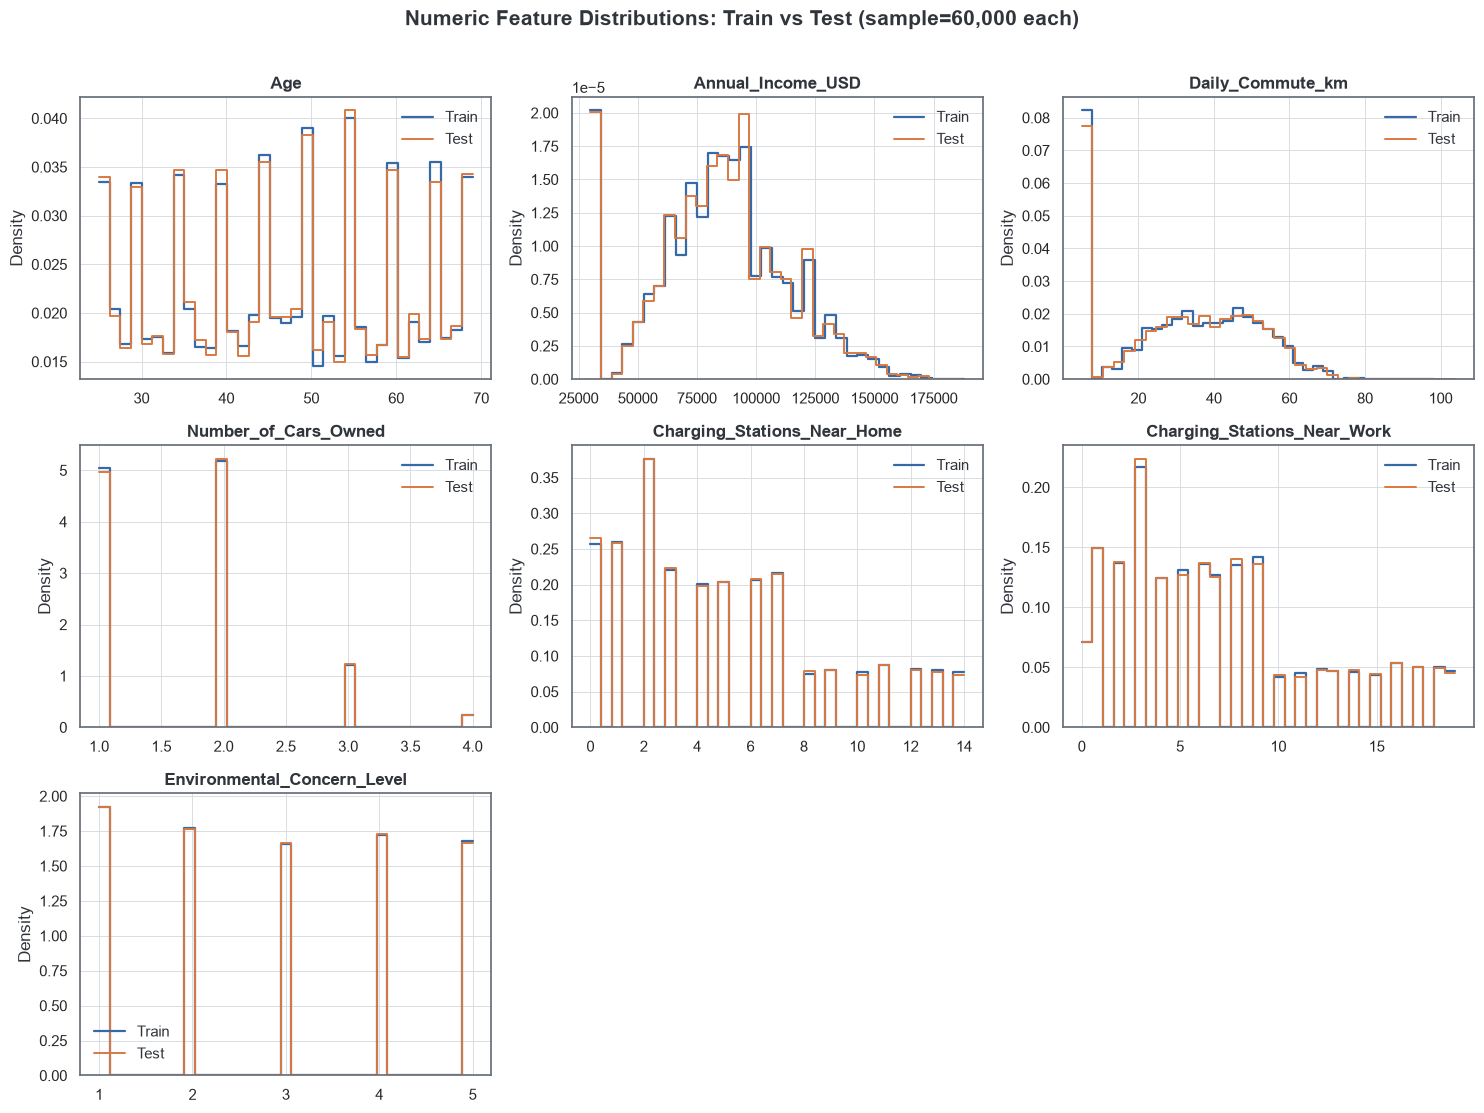

In [5]:
numeric_summary = train[numeric_features].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
numeric_summary["skew"] = train[numeric_features].skew()
display(numeric_summary.round(3))

# 仅绘图抽样；统计表使用全部数据。
plot_n = min(60_000, len(train), len(test))
train_plot = train.sample(plot_n, random_state=RANDOM_STATE)
test_plot = test.sample(plot_n, random_state=RANDOM_STATE)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for ax, feature in zip(axes, numeric_features):
    sns.histplot(
        train_plot[feature], bins=35, stat="density", element="step", fill=False,
        color=COLORS["blue"], linewidth=1.6, label="Train", ax=ax,
    )
    sns.histplot(
        test_plot[feature], bins=35, stat="density", element="step", fill=False,
        color=COLORS["orange"], linewidth=1.4, label="Test", ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
for ax in axes[len(numeric_features):]:
    ax.axis("off")
fig.suptitle(f"Numeric Feature Distributions: Train vs Test (sample={plot_n:,} each)", y=1.01, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Train/Test 分布漂移

数值特征漂移（SMD；经验上 |SMD| < 0.1 通常较小）：


,train_mean,test_mean,SMD,abs_SMD
Number_of_Cars_Owned,1.7126,1.7161,0.0048,0.0048
Charging_Stations_Near_Work,7.1763,7.1556,-0.0040,0.0040
Charging_Stations_Near_Home,4.9604,4.9507,-0.0025,0.0025
Age,47.0392,47.0708,0.0025,0.0025
Annual_Income_USD,84769.2670,84799.5084,0.0011,0.0011
Environmental_Concern_Level,2.9355,2.9346,-0.0006,0.0006
Daily_Commute_km,32.1583,32.1593,0.0001,0.0001


类别特征最大占比差（百分点）：


,max_abs_share_diff_pp
feature,
Range_Anxiety_Level,0.1711
Subsidy_Available,0.1455
City_Type,0.1347
Current_Car_Type,0.0750
Home_Charging_Possible,0.0662
Gender,0.0200


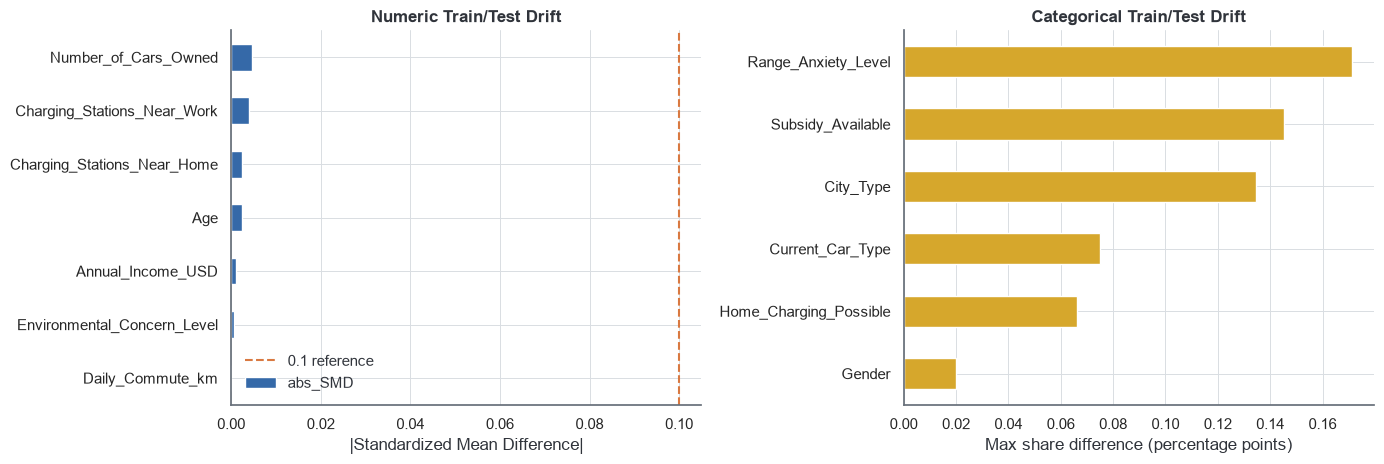

In [6]:
def standardized_mean_difference(train_s: pd.Series, test_s: pd.Series) -> float:
    pooled_sd = np.sqrt((train_s.var(ddof=1) + test_s.var(ddof=1)) / 2)
    return 0.0 if pooled_sd == 0 else (test_s.mean() - train_s.mean()) / pooled_sd


numeric_drift = pd.DataFrame({
    "train_mean": train[numeric_features].mean(),
    "test_mean": test[numeric_features].mean(),
    "SMD": [standardized_mean_difference(train[c], test[c]) for c in numeric_features],
})
numeric_drift["abs_SMD"] = numeric_drift["SMD"].abs()
numeric_drift = numeric_drift.sort_values("abs_SMD", ascending=False)

categorical_drift_rows = []
for feature in categorical_features:
    train_share = train[feature].value_counts(normalize=True)
    test_share = test[feature].value_counts(normalize=True)
    aligned = pd.concat([train_share, test_share], axis=1, keys=["train", "test"]).fillna(0)
    categorical_drift_rows.append({
        "feature": feature,
        "max_abs_share_diff_pp": (aligned["test"] - aligned["train"]).abs().max() * 100,
    })
categorical_drift = pd.DataFrame(categorical_drift_rows).set_index("feature").sort_values(
    "max_abs_share_diff_pp", ascending=False
)

print("数值特征漂移（SMD；经验上 |SMD| < 0.1 通常较小）：")
display(numeric_drift.round(4))
print("类别特征最大占比差（百分点）：")
display(categorical_drift.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
numeric_drift.sort_values("abs_SMD").plot.barh(
    y="abs_SMD", legend=False, color=COLORS["blue"], ax=axes[0]
)
axes[0].axvline(0.1, color=COLORS["orange"], linestyle="--", linewidth=1.5, label="0.1 reference")
axes[0].set(title="Numeric Train/Test Drift", xlabel="|Standardized Mean Difference|", ylabel="")
axes[0].legend(frameon=False)
categorical_drift.sort_values("max_abs_share_diff_pp").plot.barh(
    y="max_abs_share_diff_pp", legend=False, color=COLORS["gold"], ax=axes[1]
)
axes[1].set(title="Categorical Train/Test Drift", xlabel="Max share difference (percentage points)", ylabel="")
sns.despine()
plt.tight_layout()
plt.show()

SMD 和类别占比差只衡量边际分布，不能排除特征交互或条件分布漂移；但它们适合作为快速、可解释的首轮检查。当前结果没有显示值得警惕的单变量漂移。

### 7. 类别特征与购买意愿

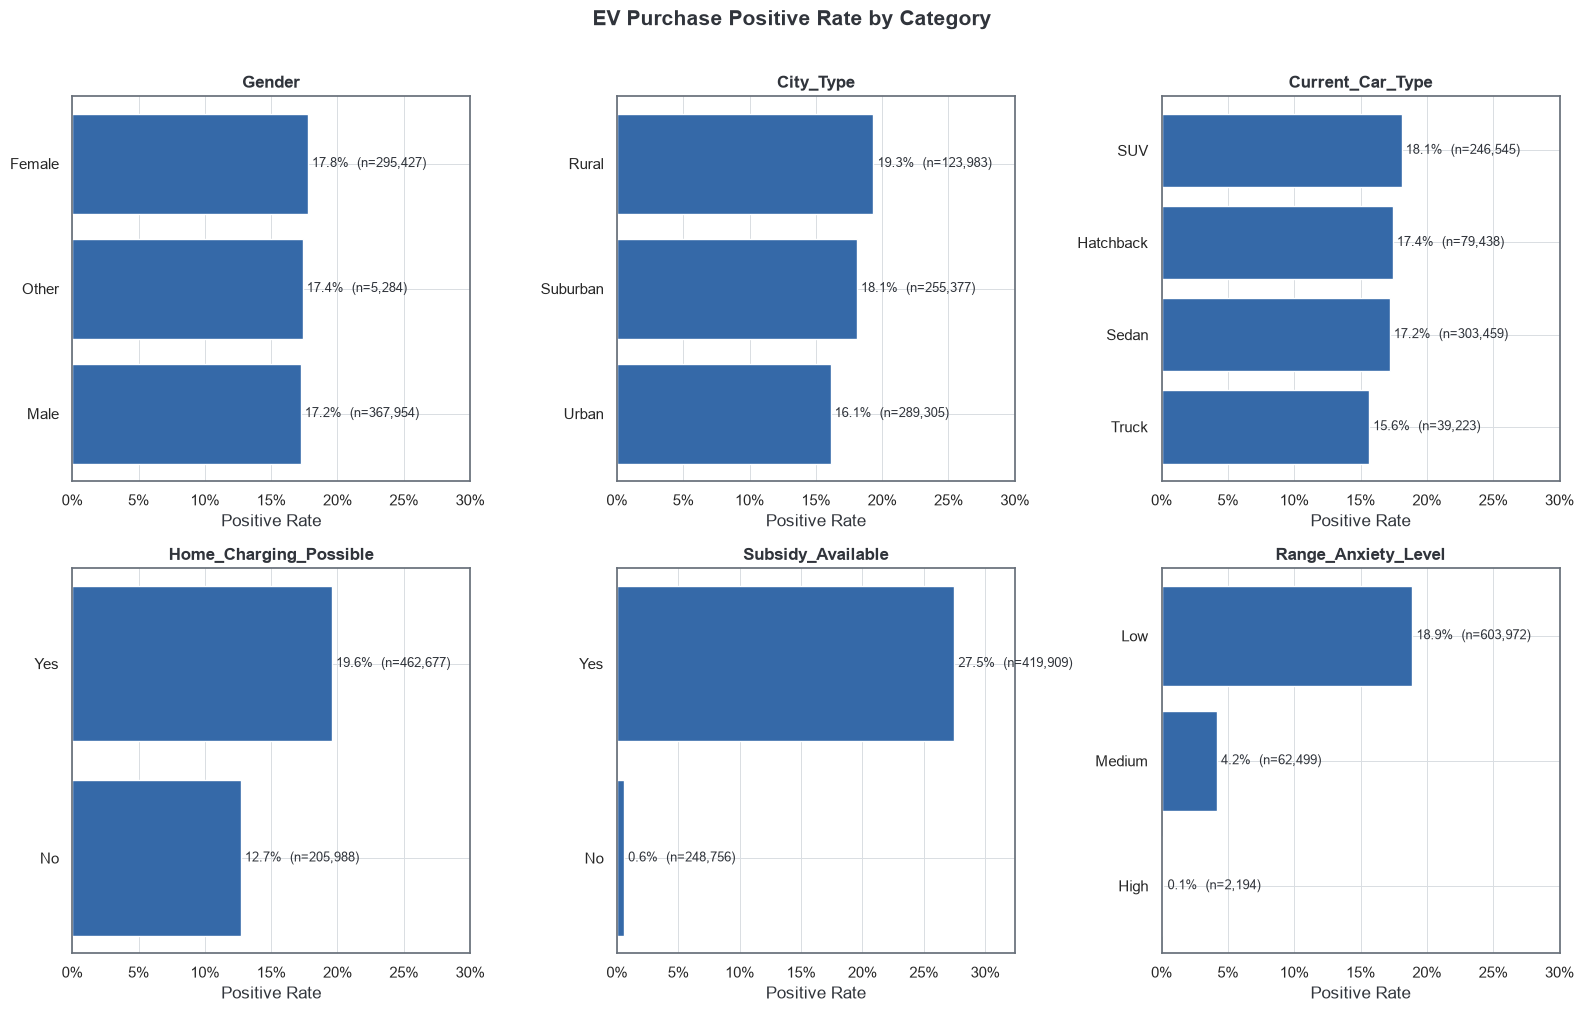

,,positive_rate,samples
feature,category,,
Subsidy_Available,Yes,27.47%,"419,909"
Home_Charging_Possible,Yes,19.58%,"462,677"
City_Type,Rural,19.34%,"123,983"
Range_Anxiety_Level,Low,18.90%,"603,972"
Current_Car_Type,SUV,18.10%,"246,545"
City_Type,Suburban,18.09%,"255,377"
Gender,Female,17.76%,"295,427"
Current_Car_Type,Hatchback,17.43%,"79,438"
Gender,Other,17.37%,"5,284"


In [7]:
category_rate_tables = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feature in zip(axes.ravel(), categorical_features):
    rates = (
        pd.DataFrame({feature: train[feature], "target": target_binary})
        .groupby(feature, observed=True)["target"]
        .agg(positive_rate="mean", samples="size")
        .sort_values("positive_rate")
    )
    category_rate_tables[feature] = rates
    bars = ax.barh(rates.index.astype(str), rates["positive_rate"], color=COLORS["blue"])
    ax.set_xlim(0, max(0.3, rates["positive_rate"].max() * 1.18))
    ax.set(title=feature, xlabel="Positive Rate", ylabel="")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.bar_label(
        bars,
        labels=[f"{rate:.1%}  (n={n:,})" for rate, n in zip(rates["positive_rate"], rates["samples"])],
        padding=3,
        fontsize=9,
    )
fig.suptitle("EV Purchase Positive Rate by Category", y=1.01, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

category_rate_long = pd.concat(category_rate_tables, names=["feature", "category"])
category_rate_display = category_rate_long.sort_values("positive_rate", ascending=False).copy()
category_rate_display["positive_rate"] = category_rate_display["positive_rate"].map(lambda x: f"{x:.2%}")
category_rate_display["samples"] = category_rate_display["samples"].map(lambda x: f"{x:,}")
display(category_rate_display)

补贴可用性和里程焦虑的组间差异最突出，家庭充电条件也有明显区分度。`Range_Anxiety_Level=High` 只有 2,194 个样本且正类极少，交叉验证时应确认每折都覆盖该小群体。

### 8. 数值特征与购买意愿

,pearson_with_target,mean_No,mean_Yes,mean_diff_Yes_minus_No
Environmental_Concern_Level,0.4641,2.6304,4.3773,1.7469
Annual_Income_USD,0.2257,81794.5886,98827.3029,17032.7144
Daily_Commute_km,-0.0459,32.5535,30.2907,-2.2628
Charging_Stations_Near_Home,-0.0164,4.9899,4.8208,-0.1691
Charging_Stations_Near_Work,-0.0122,7.2055,7.0384,-0.1671
Age,-0.0074,47.0833,46.8307,-0.2526
Number_of_Cars_Owned,0.0039,1.7113,1.7188,0.0075


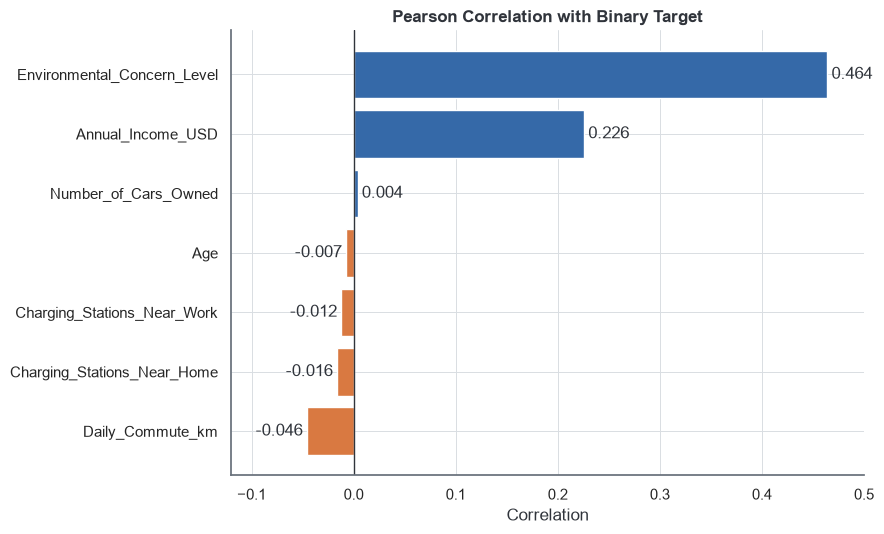

In [8]:
numeric_target_stats = pd.DataFrame({
    "pearson_with_target": train[numeric_features].corrwith(target_binary),
    "mean_No": train.loc[target_binary.eq(0), numeric_features].mean(),
    "mean_Yes": train.loc[target_binary.eq(1), numeric_features].mean(),
})
numeric_target_stats["mean_diff_Yes_minus_No"] = (
    numeric_target_stats["mean_Yes"] - numeric_target_stats["mean_No"]
)
numeric_target_stats = numeric_target_stats.sort_values("pearson_with_target", key=np.abs, ascending=False)
display(numeric_target_stats.round(4))

plot_data = numeric_target_stats.sort_values("pearson_with_target")
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [COLORS["orange"] if v < 0 else COLORS["blue"] for v in plot_data["pearson_with_target"]]
bars = ax.barh(plot_data.index, plot_data["pearson_with_target"], color=colors)
ax.axvline(0, color=COLORS["charcoal"], linewidth=1)
ax.set(title="Pearson Correlation with Binary Target", xlabel="Correlation", ylabel="")
ax.set_xlim(-0.12, 0.50)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in plot_data["pearson_with_target"]], padding=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### 9. 关键数值特征的分箱正类率

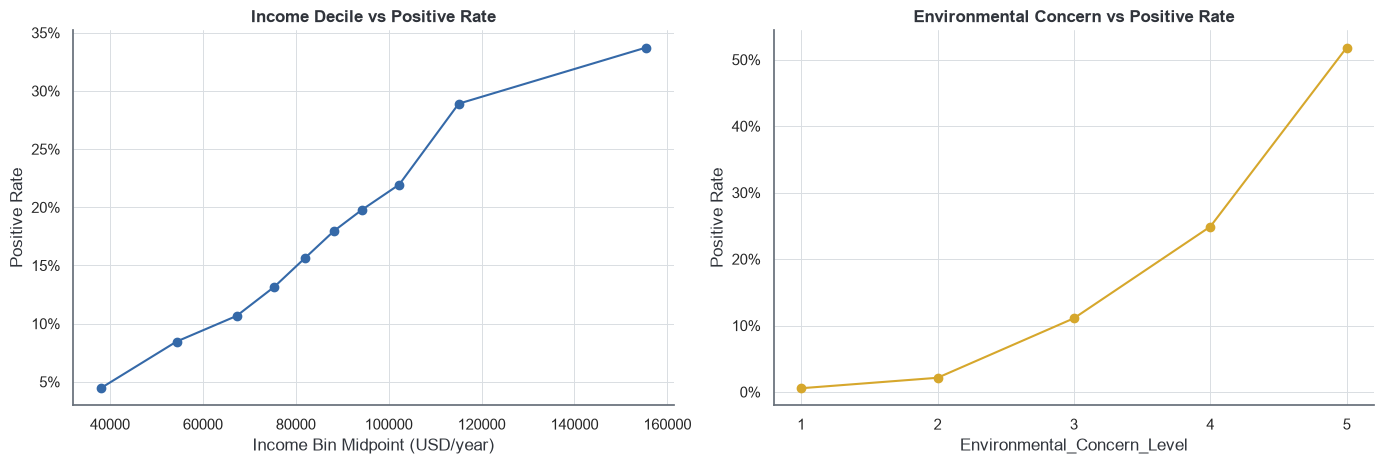

,positive_rate,samples
Annual_Income_USD,,
"(29999.999, 45980.0]",4.45%,"66,942"
"(45980.0, 62671.0]",8.46%,"66,861"
"(62671.0, 71832.0]",10.66%,"66,834"
"(71832.0, 78915.0]",13.16%,"66,844"
"(78915.0, 84880.0]",15.61%,"66,977"
"(84880.0, 91619.0]",17.97%,"67,013"
"(91619.0, 96748.0]",19.77%,"66,616"
"(96748.0, 107798.0]",21.96%,"66,854"
"(107798.0, 122349.0]",28.90%,"66,970"


,positive_rate,samples
Environmental_Concern_Level,,
1.0,0.57%,"147,476"
2.0,2.14%,"135,133"
3.0,11.09%,"127,351"
4.0,24.88%,"130,469"
5.0,51.83%,"128,236"


In [9]:
income_bin = pd.qcut(train["Annual_Income_USD"], q=10, duplicates="drop")
income_rate = target_binary.groupby(income_bin, observed=True).agg(positive_rate="mean", samples="size")
income_rate["midpoint"] = [interval.mid for interval in income_rate.index]

concern_rate = target_binary.groupby(train["Environmental_Concern_Level"], observed=True).agg(
    positive_rate="mean", samples="size"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(income_rate["midpoint"], income_rate["positive_rate"], marker="o", color=COLORS["blue"])
axes[0].set(title="Income Decile vs Positive Rate", xlabel="Income Bin Midpoint (USD/year)", ylabel="Positive Rate")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].ticklabel_format(style="plain", axis="x")
axes[1].plot(concern_rate.index, concern_rate["positive_rate"], marker="o", color=COLORS["gold"])
axes[1].set(title="Environmental Concern vs Positive Rate", xlabel="Environmental_Concern_Level", ylabel="Positive Rate")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set_xticks(sorted(train["Environmental_Concern_Level"].unique()))
sns.despine()
plt.tight_layout()
plt.show()

income_rate_display = income_rate[["positive_rate", "samples"]].copy()
income_rate_display["positive_rate"] = income_rate_display["positive_rate"].map(lambda x: f"{x:.2%}")
income_rate_display["samples"] = income_rate_display["samples"].map(lambda x: f"{x:,}")
concern_rate_display = concern_rate.copy()
concern_rate_display["positive_rate"] = concern_rate_display["positive_rate"].map(lambda x: f"{x:.2%}")
concern_rate_display["samples"] = concern_rate_display["samples"].map(lambda x: f"{x:,}")
display(income_rate_display)
display(concern_rate_display)

收入和环境关注度的分箱正类率总体呈上升关系，提示树模型可自然捕捉非线性阈值；线性模型则可考虑标准化、分箱或样条变换。分箱图仍是描述性证据，不应解读为提升收入或关注度会直接导致购买。

### 10. 数值特征之间的相关结构

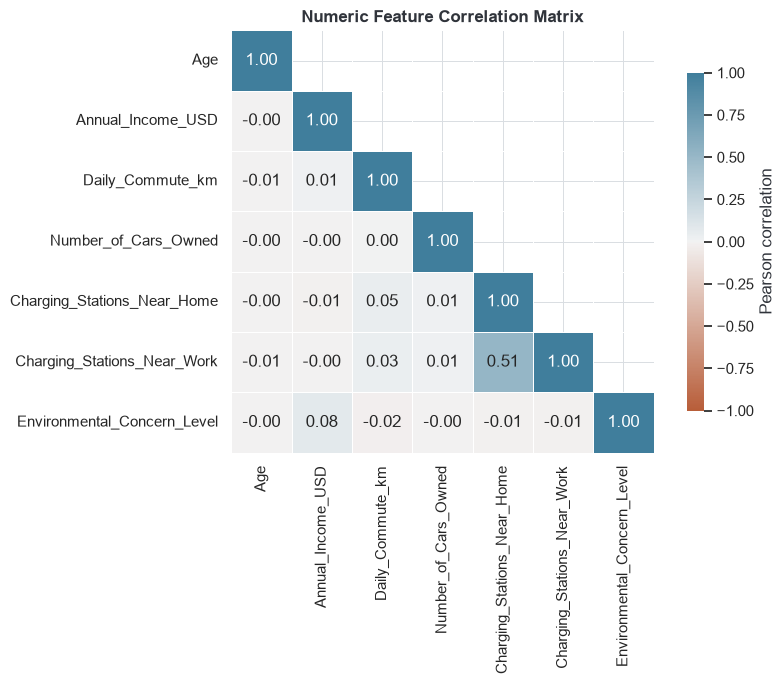

In [10]:
correlation = train[numeric_features].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation,
    mask=mask,
    cmap=sns.diverging_palette(25, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### 11. 提交文件约束检查

In [11]:
submission_checks = {
    "行数与 test 一致": len(sample_submission) == len(test),
    "列名正确": sample_submission.columns.tolist() == [ID_COL, TARGET],
    "id 与 test 完全同序": sample_submission[ID_COL].equals(test[ID_COL]),
    "预测值位于 [0, 1]": sample_submission[TARGET].between(0, 1).all(),
}
display(pd.Series(submission_checks, name="passed").to_frame())
print(f"样例预测常数: {sample_submission[TARGET].iloc[0]:.6f}")
print(f"训练集正类率: {target_binary.mean():.6f}")

,passed
行数与 test 一致,True
列名正确,True
id 与 test 完全同序,True
"预测值位于 [0, 1]",True


样例预测常数: 0.174645
训练集正类率: 0.174645


样例提交中的常数恰好等于训练集正类率，可把它视为最简单的概率基线。正式预测文件必须保留测试集 `id` 的原始顺序，并输出 `Yes` 的概率而不是 Yes/No 标签。

## Takeaways

1. **数据可直接进入首轮建模。** 当前版本无缺失、重复或未知类别，train/test 边际分布也高度接近。
2. **验证设计要处理不平衡。** 使用 `StratifiedKFold`，固定随机种子，并将 17.46% 正类率常数预测作为概率基线。
3. **优先测试强信号及交互。** 环境关注度、收入、补贴、里程焦虑和家庭充电条件最值得优先关注；可检验 `Subsidy_Available × Annual_Income_USD`、`Range_Anxiety_Level × Charging_Stations_*` 等交互。
4. **谨防合成数据捷径。** `id` 必须排除；极强单变量关系可能来自生成机制，应通过分层交叉验证和 train/test 漂移监控确认泛化。
5. **下一步建议。** 建立统一预处理管线，对比 Logistic Regression、CatBoost/LightGBM/XGBoost 或 HistGradientBoosting；使用 out-of-fold 预测比较官方指标，并检查概率校准。模型与阈值选择必须服从竞赛页公布的正式评分指标。